# Analyse des prénoms aux États-Unis

## Objectif

Manipuler un jeu de données réel sur les prénoms donnés aux États-Unis afin de :

- réviser les bases de Python : listes, dictionnaires et structures tabulaires ;
- charger et contrôler des données avec `pandas` ;
- nettoyer et préparer les données ;
- réaliser des analyses exploratoires avec `groupby`, `pivot_table` et `merge` ;
- calculer des statistiques descriptives ;
- produire des visualisations avec `matplotlib` et `seaborn`.

> **Jeu de données** : fichiers `yobAAAA.txt` issus des statistiques de prénoms de la Social Security Administration (SSA).  
> Chaque ligne contient `prénom, genre, nombre de naissances`. Les fichiers sont disponibles à partir de 1880.
> Seuls les prénoms avec au moins 5 occurrences dans une année sont publiés.

## Plan

1. Introduction et mise en contexte
2. Nettoyage et préparation des données
3. Analyse exploratoire
4. Visualisation
5. Synthèse

**Exemple de question à laquelle on veut pouvoir répondre :** comment l'usage des prénoms évolue-t-il au fil du temps ?


## 1. Introduction et mise en contexte

### 1.1 Comprendre une ligne du fichier

Un fichier `yob1880.txt` contient trois informations :

| Colonne | Signification |
|---|---|
| `name` | prénom |
| `genre` | `F` ou `M` |
| `births` | nombre de naissances portant ce prénom cette année-là |

Il n'y a pas d'en-tête dans les fichiers. L'année est portée par le nom du fichier (`yob1880.txt`, `yob1881.txt`, etc.).

### 1.2 Révision rapide : listes, dictionnaires et DataFrame

Avant `pandas`, on peut représenter une ligne avec une liste ou un dictionnaire.


In [1]:
# Une ligne représentée avec une liste
ligne = ["Mary", "F", 7065]

# Une ligne représentée avec un dictionnaire
ligne_dict = {
    "name": "Mary",
    "genre": "F",
    "births": 7065
}

ligne, ligne_dict

(['Mary', 'F', 7065], {'name': 'Mary', 'genre': 'F', 'births': 7065})

In [4]:
from pathlib import Path

BASE_DIR = Path("__file__").resolve().parent.parent
DATA_DIR = BASE_DIR / "data"
NAMES_DATA_DIR = DATA_DIR / "names"

with open(NAMES_DATA_DIR / "yob2025.txt") as fi:
    for line in fi:
        print(line, end='') # le paramètre end permet de personnaliser l'affichage

Olivia,F,13544
Charlotte,F,13400
Emma,F,12754
Amelia,F,12699
Sophia,F,12561
Mia,F,11078
Isabella,F,10666
Evelyn,F,9123
Sofia,F,8252
Eliana,F,8191
Ava,F,7732
Eleanor,F,7649
Violet,F,7546
Ailany,F,7136
Aurora,F,7065
Harper,F,6792
Elizabeth,F,6760
Lily,F,6673
Camila,F,6591
Nora,F,6380
Hazel,F,6318
Penelope,F,6225
Chloe,F,6203
Ellie,F,6176
Lucy,F,6176
Aria,F,6130
Luna,F,6076
Isla,F,6012
Ella,F,5831
Lainey,F,5738
Zoe,F,5646
Scarlett,F,5644
Gianna,F,5634
Emily,F,5451
Valentina,F,5354
Layla,F,5338
Avery,F,5267
Grace,F,5127
Ivy,F,5117
Madison,F,4945
Abigail,F,4941
Elena,F,4836
Mila,F,4796
Willow,F,4763
Emilia,F,4677
Nova,F,4657
Naomi,F,4644
Riley,F,4441
Eloise,F,4251
Sadie,F,4168
Delilah,F,4137
Stella,F,4136
Josephine,F,4126
Victoria,F,4027
Sophie,F,3984
Hannah,F,3973
Lillian,F,3966
Leah,F,3880
Adeline,F,3864
Leilani,F,3792
Iris,F,3729
Maya,F,3712
Clara,F,3601
Ruby,F,3554
Alice,F,3547
Genesis,F,3527
Paisley,F,3508
Claire,F,3487
Zoey,F,3427
Eden,F,3362
Madelyn,F,3362
Vivian,F,3362
Millie,F,3353

Le `DataFrame` de `pandas` permet de manipuler efficacement un grand ensemble de lignes et de colonnes.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# pd.read_csv?

In [6]:
# Vérifier le dossier de données et quelques fichiers disponibles
print("Dossier des données :", NAMES_DATA_DIR)
print("Nombre de fichiers :", len(list(NAMES_DATA_DIR.iterdir())))
print("Premiers fichiers :", sorted(list(NAMES_DATA_DIR.iterdir()))[:2])

Dossier des données : /home/jupyterhub-users/lvijayarajah/project/introduction-python-main/data/names
Nombre de fichiers : 146
Premiers fichiers : [PosixPath('/home/jupyterhub-users/lvijayarajah/project/introduction-python-main/data/names/yob1880.txt'), PosixPath('/home/jupyterhub-users/lvijayarajah/project/introduction-python-main/data/names/yob1881.txt')]


### 1.3 Charger une année

On commence par un seul fichier pour comprendre le format avant de charger l'ensemble des années.


In [7]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[HashableT, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: 

In [8]:
df2025 = pd.read_csv(
    NAMES_DATA_DIR / "yob2025.txt",
    header=None,
    names=["name", "genre", "births"]
)

print(df2025.head(n=10))

# chaque objet est documenté
# df2025?

        name genre  births
0     Olivia     F   13544
1  Charlotte     F   13400
2       Emma     F   12754
3     Amelia     F   12699
4     Sophia     F   12561
5        Mia     F   11078
6   Isabella     F   10666
7     Evelyn     F    9123
8      Sofia     F    8252
9     Eliana     F    8191


In [9]:
df2025.info()
df2025.shape

<class 'pandas.DataFrame'>
RangeIndex: 31227 entries, 0 to 31226
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    31227 non-null  str  
 1   genre   31227 non-null  str  
 2   births  31227 non-null  int64
dtypes: int64(1), str(2)
memory usage: 732.0 KB


(31227, 3)

Voici les principales fonctions d'import disponibles :

fonction|usage
-|-
read_clipboard|à partir d'une copie mémoire
read_csv|à partir d'un fichier *CSV* (Comma-Separated Value)
read_excel|à partir d'un fichier *Excel*
read_html|à partir d'un fichier *HTML* (recherche des *< table >*)
read_json|à partir d'un fichier *JSON*
read_sql|à partir d'une requête *SQL*
read_sas|à partir d'un fichier *SAS*
read_table|à partir d'un fichier tabulaire quelconque

## 2. Nettoyage et préparation des données

### 2.1 Charger toutes les années

On construit un seul `DataFrame` avec quatre colonnes : `year`, `name`, `genre` et `births`.


In [10]:
frames = []  # on part d'une liste vide

for filename in sorted(NAMES_DATA_DIR.iterdir()):  # on utilise la méthode iterdir pour parcourir les fichiers
    if filename.name.startswith("yob") and filename.name.endswith(".txt"):
        year = int(filename.name[3:7]) # on extrait l'année sachant que les noms des fichiers sont au format yobAAAA.txt
        temp = pd.read_csv( # on lit chaque fichier dans un nouveau DataFrame
            NAMES_DATA_DIR / filename,
            header=None,
            names=["name", "genre", "births"]
        )
        temp["year"] = year # on lui ajoute une colonne avec l'année extraite
        frames.append(temp) # on ajout le DataFrame à la liste de Dataframe

names_df = pd.concat(frames, ignore_index=True)  # on concatène tous les DataFrames de la liste
names_df = names_df[["year", "name", "genre", "births"]]  # on modifie l'ordre des colonnes du DataFrame global

names_df.head()

,year,name,genre,births
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746


#### Exercice 1 : Informations sur le dataframe

En utilisant les méthodes `unique`, `nunique`, `max` et `min`, remplir les informations ci-dessous.

In [15]:
print("Dimensions :", names_df.shape)
print("Années :", "de", names_df["year"].min(), "à", max(names_df.year))
print("Prénoms distincts :", names_df["name"].nunique()) 
print("Genres :", names_df["genre"].unique())

Dimensions : (2181032, 4)
Années : de 1880 à 2025
Prénoms distincts : 105966
Genres : <StringArray>
['F', 'M']
Length: 2, dtype: str


### 2.2 Contrôle des types et des valeurs manquantes

Un nettoyage commence par un diagnostic : types, valeurs manquantes, doublons et valeurs impossibles.

**Important :** on ne doit pas inventer de correction. On identifie d'abord les anomalies réellement présentes dans le jeu de données.


In [16]:
names_df.info()
print("\nValeurs manquantes :")
print(names_df.isna().sum())

print("\nLignes dupliquées :", names_df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2181032 entries, 0 to 2181031
Data columns (total 4 columns):
 #   Column  Dtype
---  ------  -----
 0   year    int64
 1   name    str  
 2   genre   str  
 3   births  int64
dtypes: int64(2), str(2)
memory usage: 66.6 MB

Valeurs manquantes :
year      0
name      0
genre     0
births    0
dtype: int64

Lignes dupliquées : 0


#### Exercice 2
Vérifier la cohérence des données (pas de prénoms avec moins de 5 naissances par an, les prénoms ont au moins 2 lettres, le genre est F ou M)

In [21]:
# Vérifications de cohérence
print("Naissances < 5 :", len(names_df[names_df["births"] < 5]))
print("Prénoms d'une seule lettre :", (names_df["name"].str.len() < 2).sum())
print("Genres :", (~ names_df["genre"].isin(["F", "M"])).sum())

Naissances < 5 : 0
Prénoms d'une seule lettre : 0
Genres : 0


### 2.3 Les objets de pandas

#### 2.3.1 Les Series

On accède aux colonnes d'un `DataFrame` avec l'opérateur **[]** et en utilisant le nom de la colonne.

L'objet obtenu a pour classe `Series`. Un objet `Series` est une structure de données unidimensionnelle représentant un tableau de données en général homogène.

L'objet `Series` obtenu possède un index identique à celui du `DataFrame` et un tableau de valeurs correspondant à la colonne du `DataFrame`. Il possède également un nom qui est celui de la colonne dont il est tiré. En fait, c'est une vue du `DataFrame` : toute modification de la `Series` est répercutée sur le `DataFrame`.

In [22]:
name_series = names_df["name"]
name_series

0               Mary
1               Anna
2               Emma
3          Elizabeth
4             Minnie
             ...    
2181027       Zyquan
2181028         Zyre
2181029      Zyreese
2181030        Zyrin
2181031       Zyrion
Name: name, Length: 2181032, dtype: str

In [23]:
print(
    type(name_series), 
    name_series.name, 
    name_series.values, 
    name_series.index, 
    name_series.shape,
    name_series.head(),
    name_series.tail(),
    name_series.nunique(),
    sep= "\n-----\n")

<class 'pandas.Series'>
-----
name
-----
<StringArray>
[     'Mary',      'Anna',      'Emma', 'Elizabeth',    'Minnie',  'Margaret',
       'Ida',     'Alice',    'Bertha',     'Sarah',
 ...
    'Zunair',   'Zyairre',     'Zydan',     'Zykir',     'Zylar',    'Zyquan',
      'Zyre',   'Zyreese',     'Zyrin',    'Zyrion']
Length: 2181032, dtype: str
-----
RangeIndex(start=0, stop=2181032, step=1)
-----
(2181032,)
-----
0         Mary
1         Anna
2         Emma
3    Elizabeth
4       Minnie
Name: name, dtype: str
-----
2181027     Zyquan
2181028       Zyre
2181029    Zyreese
2181030      Zyrin
2181031     Zyrion
Name: name, dtype: str
-----
105966


Décompte du nombre d'occurences des valeurs uniques d'un objet `Series`

In [24]:
names_df["births"].value_counts()

births
5       304207
6       216704
7       163583
8       129464
9       104505
         ...  
6480         1
6208         1
6072         1
5578         1
4413         1
Name: count, Length: 14006, dtype: int64

##### Exercice 3

Quelles sont les valeurs attendues pour le nombre de valeurs uniques pour les colonnes `genre` et `year` ? 
Vérifiez sur les données.

Donner le décompte des prénoms.

Donner le décompte des genres. Comment interpréter le résultat ?

Donner les 10 années avec le plus de prénoms (+ genre) distincts ? Que constate-t-on ?

In [30]:
print(
    names_df["genre"].nunique(),
    names_df["year"].nunique(),
    names_df["name"].value_counts(),
    names_df["genre"].value_counts(),
    names_df["year"].value_counts().head(10),
    names_df["year"].value_counts().tail(10))

2 146 name
Jessie     292
Ollie      292
Marion     292
Jean       292
Francis    292
          ... 
Zephryn      1
Zhylo        1
Zyairre      1
Zydan        1
Zyreese      1
Name: count, Length: 105966, dtype: int64 genre
F    1280901
M     900131
Name: count, dtype: int64 year
2008    35107
2007    34978
2009    34739
2006    34111
2010    34111
2011    33950
2012    33784
2013    33349
2014    33313
2015    33189
Name: count, dtype: int64 year
1888    2651
1889    2590
1886    2392
1887    2373
1884    2297
1885    2294
1882    2127
1883    2084
1880    2000
1881    1934
Name: count, dtype: int64


#### 2.3.2 Opérations sur les Series

Toutes les opérations vectorielles des *ndarray* de NumPy sont disponibles pour les objets *Series* :
- fonctions mathématiques ususelles : `abs()`, `sqrt()`, `sign()`, `floor()`, `rint()`
- logique, trigonométrie, logarithme, exponentielle
- calcul vectoriel avec une valeur scalaire ou un autre objet *Series*
- comparaisons avec une valeur scalaire ou un autre objet *Series*
- fonctions statistiques ususelles : `sum()`, `min()`, `max()`, `mean()`, `median()`, `std()`, `cumsum()`, `cumprod()` (cumuls des sommes et produits)

In [31]:
births_series = names_df["births"]
print(
    births_series.sum(),
    births_series.min(),
    births_series.max(),
    births_series * 3, 
    sep="\n ------- \n")

375362447
 ------- 
5
 ------- 
99692
 ------- 
0          21195
1           7812
2           6009
3           5817
4           5238
           ...  
2181027       15
2181028       15
2181029       15
2181030       15
2181031       15
Name: births, Length: 2181032, dtype: int64


In [32]:
print(
    (names_df["year"] + names_df["births"]).tail(),
    (names_df["births"] == 5).tail(),
    (names_df["births"].isin(range(10))).tail(),
    (names_df["year"] == names_df["births"]).head(),
    sep="\n ------- \n ",
)

2181027    2030
2181028    2030
2181029    2030
2181030    2030
2181031    2030
dtype: int64
 ------- 
 2181027    True
2181028    True
2181029    True
2181030    True
2181031    True
Name: births, dtype: bool
 ------- 
 2181027    True
2181028    True
2181029    True
2181030    True
2181031    True
Name: births, dtype: bool
 ------- 
 0    False
1    False
2    False
3    False
4    False
dtype: bool


L'opérateur `str` permet de traiter une *Series* comportant des chaînes de caractères et d'obtenir une nouvelle *Series* avec le résultat des opérations appliquées à chacun des éléments.

Grâce à l'opérateur *str*, la plupart des fonctions Python dédiées aux chaînes de caractères sont disponibles en méthodes de *Series* composées de chaînes : `len()`, `startswith()`, `contains()`, `endswith()`, `split()`, `lower()`...

Ces méthodes retournent un objet *Series* composé du résultat de la fonction appliquée élément par élément.

In [33]:
print(names_df["name"].str.len().head())  # longueur des noms des 5 premiers prénoms
print(names_df["name"].head().str.len())  # quelle est la différence entre les 2 lignes ?

0    4
1    4
2    4
3    9
4    6
Name: name, dtype: int64
0    4
1    4
2    4
3    9
4    6
Name: name, dtype: int64


La méthode `apply()` permet de calculer une fonction (ou une lambda) avec chacune des valeurs d'un objet *Series*.

Elle retourne un objet *Series* ayant le même index et dont les valeurs correspondent à l'application de la fonction à chacun des éléments.

In [35]:
import numpy as np
print(births_series.apply(np.sqrt))
births_series.apply(lambda x: 2 * x * x - x + 1)

0          84.053554
1          51.029403
2          44.754888
3          44.034078
4          41.785165
             ...    
2181027     2.236068
2181028     2.236068
2181029     2.236068
2181030     2.236068
2181031     2.236068
Name: births, Length: 2181032, dtype: float64


0          99821386
1          13559029
2           8022016
3           7517504
4           6095287
             ...   
2181027          46
2181028          46
2181029          46
2181030          46
2181031          46
Name: births, Length: 2181032, dtype: int64

##### Exercice 4

Calculer le minimum et le maximum des longueurs des prénoms.

Donner le décompte des longueurs des prénoms.

In [40]:
print(names_df["name"].str.len().min(), names_df["name"].str.len().max())
pd.Series(names_df["name"].unique()).str.len().value_counts()

2 15


6     29716
7     27281
5     18127
8     14931
4      5879
9      5735
10     1873
3      1049
11      694
12      258
13      158
2       155
14       70
15       40
Name: count, dtype: int64

#### 2.3.3 Les DataFrames

Un *DataFrame* est un tableau de données tel que l'on en rencontre fréquemment dans d'autres environnements informatiques : une table dans une base de données, une feuille de calcul en Excel, un *data.frame* du langage R, un fichier de données CSV, TSV...

En général, un tableau est constitué d'un ensemble d'enregistrements. Chaque ligne représente un enregistrement particulier et les diférentes colonnes matérialisent différentes caractéristiques de chaque enregistrement.

Les objets contenu dans un *DataFrame* peuvent être de différents types :
- booléen : `bool`
- nombre entier : `int`
- nombre flottant : `float`
- horodatage : `Timestamp`
- chaîne de caractères : `object` (le type le plus général)

A noter :
- *pandas* essaie d'utiliser le type le plus approprié en fonction des objets de chaque colonne.
- si le type d'une colonne est *object* (le type le plus général), il peut y avoir des objets qui ne sont pas des chaînes de caractères.

Il est possible d'afficher les caractéristiques des *DataFrame* obtenus précédemment :
- le type de l'objet obtenu par la fonction *read_csv()*
- les dimensions du *DataFrame*
- l'index du *DataFrame* (par défaut les entiers de 0 à L-1 où L est le nombre de lignes du *DataFrame*)
- les noms des colonnes du *DataFrame*
- des informations colonne par colonne et aussi sur l'empreinte mémoire

In [41]:
print(
    type(names_df),  # appel de la fonction Python type()
    names_df.shape,  # accès à la variable d'instance shape
    len(names_df),  # nombre de lignes
    names_df.size,  # nombre total d'éléments
    names_df.index,  # index par défaut, numérotation à partir de 0 en Python
    names_df.index.is_unique,  # l'index est bien unique
    names_df.columns,  # liste des colonnes, numérotation automatique
    names_df.info(),  # informations dont l'empreinte mémoire du DataFrame
    names_df.values,  # le ndarray sous-jacent, il ressemble à la liste de listes fabriquée manuellement
    names_df.values[0],  # c'est un ndarray lui-même composé de sous-ndarray
    sep="\n ----------- \n",
)

<class 'pandas.DataFrame'>
RangeIndex: 2181032 entries, 0 to 2181031
Data columns (total 4 columns):
 #   Column  Dtype
---  ------  -----
 0   year    int64
 1   name    str  
 2   genre   str  
 3   births  int64
dtypes: int64(2), str(2)
memory usage: 66.6 MB
<class 'pandas.DataFrame'>
 ----------- 
(2181032, 4)
 ----------- 
2181032
 ----------- 
8724128
 ----------- 
RangeIndex(start=0, stop=2181032, step=1)
 ----------- 
True
 ----------- 
Index(['year', 'name', 'genre', 'births'], dtype='str')
 ----------- 
None
 ----------- 
[[1880 'Mary' 'F' 7065]
 [1880 'Anna' 'F' 2604]
 [1880 'Emma' 'F' 2003]
 ...
 [2025 'Zyreese' 'M' 5]
 [2025 'Zyrin' 'M' 5]
 [2025 'Zyrion' 'M' 5]]
 ----------- 
[1880 'Mary' 'F' 7065]


In [42]:
print(
    names_df.head(),
    names_df.tail(),
    names_df.head().transpose(),
    names_df.head().T,
    sep="\n -------------- \n "
)

   year       name genre  births
0  1880       Mary     F    7065
1  1880       Anna     F    2604
2  1880       Emma     F    2003
3  1880  Elizabeth     F    1939
4  1880     Minnie     F    1746
 -------------- 
          year     name genre  births
2181027  2025   Zyquan     M       5
2181028  2025     Zyre     M       5
2181029  2025  Zyreese     M       5
2181030  2025    Zyrin     M       5
2181031  2025   Zyrion     M       5
 -------------- 
            0     1     2          3       4
year    1880  1880  1880       1880    1880
name    Mary  Anna  Emma  Elizabeth  Minnie
genre      F     F     F          F       F
births  7065  2604  2003       1939    1746
 -------------- 
            0     1     2          3       4
year    1880  1880  1880       1880    1880
name    Mary  Anna  Emma  Elizabeth  Minnie
genre      F     F     F          F       F
births  7065  2604  2003       1939    1746


### 2.4 Créer des variables utiles

On ajoute la décennie et la longueur du prénom. Ces variables serviront aux analyses suivantes.


In [43]:
names_df["decade"] = (names_df["year"] // 10) * 10
names_df["name_length"] = names_df["name"].str.len()

names_df.head()

,year,name,genre,births,decade,name_length
0,1880,Mary,F,7065,1880,4
1,1880,Anna,F,2604,1880,4
2,1880,Emma,F,2003,1880,4
3,1880,Elizabeth,F,1939,1880,9
4,1880,Minnie,F,1746,1880,6


### 2.5 Filtrer les données

Un masque de booléen peut être appliqué au DataFrame pour filter les données.
La conjonction de conditions est notée &, la disjonction est notée | et la négation ~.


In [44]:
masque = name_series.str.startswith("A")
masque

0          False
1           True
2          False
3          False
4          False
           ...  
2181027    False
2181028    False
2181029    False
2181030    False
2181031    False
Name: name, Length: 2181032, dtype: bool

In [45]:
name_series[masque]

1             Anna
7            Alice
10           Annie
32             Ada
53           Agnes
            ...   
2179359     Azarya
2179360    Azavier
2179361       Azem
2179362     Azhiel
2179363     Azriah
Name: name, Length: 223187, dtype: str

In [46]:
# les prénoms qui commencent par Nath
name_series[name_series.str.startswith("Emm")]

2                Emma
454          Emmaline
503             Emmie
526             Emmer
1117           Emmett
              ...    
2173323          Emma
2178161      Emmanual
2178162      Emmerick
2179684    Emmanuelle
2179685     Emmiliano
Name: name, Length: 3788, dtype: str

In [47]:
mary = names_df[names_df["name"] == "Mary"].sort_values("year")
mary.head(10)

,year,name,genre,births,decade,name_length
0,1880,Mary,F,7065,1880,4
1273,1880,Mary,M,27,1880,4
2000,1881,Mary,F,6919,1880,4
3238,1881,Mary,M,29,1880,4
3934,1882,Mary,F,8148,1880,4
5275,1882,Mary,M,30,1880,4
6061,1883,Mary,F,8012,1880,4
7406,1883,Mary,M,32,1880,4
8145,1884,Mary,F,9217,1880,4
9609,1884,Mary,M,36,1880,4


Le site de la SSA indique "To safeguard privacy, we restrict our list of names to those with at least 5 occurrences". Nous allons vérifier ce point : les valeurs de la colonne "births" doivent être toutes supérieures ou égales à 5.


On va utiliser la méthode **all()**. Elle retourne *True* si une *Series* de booléens est composée exclusivement de *True* et *False* sinon (la méthode effectue un ET logique entre tous les éléments de la *Series*). Il existe aussi une méthode **any()** qui effectue un OU logique.

In [48]:
# on utilise la méthode all() pour vérifier la condition pour tout
(names_df["births"] >= 5).all()

np.True_

In [49]:
# on vérifie également qu'il n'y a pas de prénom avec 1 seule lettre
(names_df["name"].str.len() == 1).any()

np.False_

#### Exercice 5

Quels prénoms commencent par la lettre "Z" ?

Quels prénoms se terminent par la lettre "z" ?

Quels prénoms commencent par la lettre "Z" et se terminent par la lettre "z" ?


In [56]:
print(name_series[name_series.str.startswith("Z")].unique(),
name_series[name_series.str.endswith("z")].unique())
name_series[name_series.str.startswith("Z") & name_series.str.endswith("z")].unique()

<StringArray>
[   'Zella',     'Zora',     'Zula',      'Zoe',    'Zelma',     'Zada',
    'Zetta',      'Zoa',     'Zona',     'Zena',
 ...
  'Zakhias',    'Zakoa',   'Zayann', 'Zaydriel',     'Zejd',  'Zephryn',
    'Zhylo',  'Zyairre',    'Zydan',  'Zyreese']
Length: 2288, dtype: str <StringArray>
[   'Inez',   'Fritz',    'Cruz',   'Jabez',  'Cortez',  'Lorenz',  'Ignatz',
     'Luz',   'Franz',    'Plez',
 ...
    'Truz',    'Kanz',  'Anahiz',   'Ayliz',  'Maeliz',   'Araiz',  'Nivaaz',
   'Alezz',     'Tez', 'Nooraiz']
Length: 573, dtype: str


<StringArray>
['Zyquez', 'Zoraiz']
Length: 2, dtype: str

#### Exercice 6

Afficher années et nombre de naissances de tous les prénoms comportant seulement 2 lettres.

Donner la liste des prénoms de 2 lettres.

Combien y a-t-il eu de naissances de personnes avec un prénom à 2 lettres ?

Combien y a-t-il d'années où le nombre de naissances est exactement 1000 pour au moins un prénom (+ genre) ?

In [59]:
names_df[names_df["name_length"] == 2][["year", "births"]]

,year,births
996,1880,310
1444,1880,14
1467,1880,12
1850,1880,5
2880,1881,5
...,...,...
2179118,2025,5
2179268,2025,5
2179845,2025,5
2180589,2025,5


In [60]:
names_df[names_df["name_length"] == 2]["name"].unique()

<StringArray>
['Ed', 'Wm', 'Al', 'Ab', 'Jo', 'Ah', 'Ng', 'Lu', 'Le', 'Ad',
 ...
 'Oh', 'Xi', 'Tr', 'Go', 'Ao', 'Ax', 'Yy', 'Mu', 'Ba', 'Ru']
Length: 155, dtype: str

In [61]:
names_df[names_df["name_length"] == 2]["births"].sum()

np.int64(354315)

In [63]:
names_df[names_df["births"] == 1000]["year"].nunique()

40

### 2.6 Ajouter une seconde source de données

Récupération d'un tableau d'une page web à l'aide de read_html. 

In [64]:
var = pd.read_html(
    "https://en.wikipedia.org/wiki/Demographics_of_the_United_States", 
    storage_options={'User-Agent':'Mozilla/5.0 (X11; Linux x86_64; rv:140.0) Gecko/20100101 Firefox/140.0}'}
    )

In [65]:
us_demographic = var[7]
us_demographic.columns = us_demographic.columns.get_level_values(1).str.lower()
us_demographic

,year,average population,live births,deaths,natural change,birth,death,natural change,migration change,total fertility rate[a],infant mortality rate,life expectancy (total)
0,1790,3929000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1791,4048000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1792,4172000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1793,4299000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1794,4429000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
231,2021,332100166,3664292.0,3464231.0,200061.0,11.0,10.4,0.6,1.0,1.664,5.4,76.4
232,2022,333996304,3667758.0,3279857.0,387901.0,11.0,9.8,1.2,4.5,1.656,5.6,77.5
233,2023,336755052,3596017.0,3090964.0,505053.0,10.7,9.2,1.5,6.7,1.621,5.6,78.4
234,2024,340003797,3628934.0,3072666.0,556268.0,10.7,9.0,1.7,7.9,1.599,5.5,79.0


In [66]:
us_demographic["year"] = us_demographic["year"].apply(lambda x: int(x[0:4]))
us_demographic = us_demographic[us_demographic["year"].isin(range(1880, 2026))]
us_demographic

,year,average population,live births,deaths,natural change,birth,death,natural change,migration change,total fertility rate[a],infant mortality rate,life expectancy (total)
90,1880,50262000,1965000.0,1131000.0,834000.0,39.1,22.5,16.6,3.3,NaN,NaN,NaN
91,1881,51466000,1991000.0,1146000.0,845000.0,38.7,22.3,16.4,7.0,NaN,NaN,NaN
92,1882,52893000,2024000.0,1166000.0,858000.0,38.3,22.0,16.3,10.8,NaN,NaN,NaN
93,1883,54435000,2061000.0,1187000.0,874000.0,37.9,21.8,16.1,12.3,NaN,NaN,NaN
94,1884,55826000,2090000.0,1204000.0,886000.0,37.4,21.6,15.8,9.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
231,2021,332100166,3664292.0,3464231.0,200061.0,11.0,10.4,0.6,1.0,1.664,5.4,76.4
232,2022,333996304,3667758.0,3279857.0,387901.0,11.0,9.8,1.2,4.5,1.656,5.6,77.5
233,2023,336755052,3596017.0,3090964.0,505053.0,10.7,9.2,1.5,6.7,1.621,5.6,78.4
234,2024,340003797,3628934.0,3072666.0,556268.0,10.7,9.0,1.7,7.9,1.599,5.5,79.0


## 3. Analyse exploratoire

### 3.1 Les statistiques descriptives

La colonne `births` est quantitative. On peut calculer la moyenne, la médiane et l'écart-type, mais aussi obtenir une vue d'ensemble avec `describe()`.


In [67]:
names_df["births"].describe()

count    2.181032e+06
mean     1.721031e+02
std      1.454575e+03
min      5.000000e+00
25%      7.000000e+00
50%      1.200000e+01
75%      3.200000e+01
max      9.969200e+04
Name: births, dtype: float64

In [68]:
stats_births = pd.Series({
    "moyenne": names_df["births"].mean(),
    "médiane": names_df["births"].median(),
    "écart-type": names_df["births"].std(),
    "minimum": names_df["births"].min(),
    "maximum": names_df["births"].max()
})

stats_births


moyenne         172.103136
médiane          12.000000
écart-type     1454.574619
minimum           5.000000
maximum       99692.000000
dtype: float64

### 3.2 `groupby` : total des naissances par année

`groupby` permet de découper les données en groupes puis d'appliquer une fonction d'agrégation.


In [70]:
births_by_year = (
    names_df
    .groupby("year", as_index=False)["births"]
    .sum()
)

births_by_year.tail()


,year,births
141,2021,3390343
142,2022,3386139
143,2023,3315158
144,2024,3343078
145,2025,3315343


### 3.3 Les prénoms les plus populaires par année

On trie les lignes dans chaque année et on conserve le premier prénom.


In [72]:
top_by_year = (
    names_df
    .sort_values(["year", "births"], ascending=[True, False])
    .groupby("year", as_index=False)
    .first()
)

top_by_year[["year", "name", "genre", "births"]].tail(15)


,year,name,genre,births
131,2011,Sophia,F,21863
132,2012,Sophia,F,22336
133,2013,Sophia,F,21255
134,2014,Emma,F,20970
135,2015,Emma,F,20487
136,2016,Emma,F,19550
137,2017,Emma,F,19873
138,2018,Liam,M,19977
139,2019,Liam,M,20631
140,2020,Liam,M,19865


### 3.4 Évolution d'un prénom

Pour un prénom donné, on peut comparer son nombre de naissances au fil du temps.


In [75]:
def evolution_prenom(name : str, genre=None):
    data = names_df[names_df["name"] == name]
    if genre is not None:
        data = data[data["genre"] == genre]
    return data.sort_values("year")

evolution_prenom("Lydia", "F").tail()

,year,name,genre,births,decade,name_length
2022178,2021,Lydia,F,2935,2020,5
2053954,2022,Lydia,F,2818,2020,5
2086048,2023,Lydia,F,2735,2020,5
2117881,2024,Lydia,F,2678,2020,5
2149896,2025,Lydia,F,2692,2020,5


### 3.5 Analyse par décennie

On peut agréger les données par décennie afin de dégager des tendances de long terme.


In [77]:
decade_stats = (
    names_df
    .groupby("decade")
    .agg(
        total_births=("births", "sum"),
        unique_names=("name", "nunique"),
        mean_births=("births", "mean"),
        median_births=("births", "median")
    )
    .reset_index()
)

decade_stats.head(10)


,decade,total_births,unique_names,mean_births,median_births
0,1880,2408091,3610,105.887389,13.0
1,1890,3362508,4509,113.898381,13.0
2,1900,4285123,5665,116.843622,12.0
3,1910,14831446,13528,184.216393,12.0
4,1920,22972053,15985,218.019427,12.0
5,1930,21229562,13854,232.034822,12.0
6,1940,29371685,14459,307.100280,13.0
7,1950,39451512,17019,356.733477,13.0
8,1960,37527798,19959,302.075922,13.0
9,1970,31968338,28720,191.111325,11.0


### 3.6 Comparer les genres

Calculons le nombre total de naissances et le nombre de prénoms distincts par année et par genre.


In [79]:
genre_year = (
    names_df
    .groupby(["year", "genre"])
    .agg(
        births=("births", "sum"),
        unique_names=("name", "nunique")
    )
    .reset_index()
)

genre_year.tail()


,year,genre,births,unique_names
287,2023,M,1710576,14215
288,2024,F,1620190,17726
289,2024,M,1722888,14294
290,2025,F,1607267,17297
291,2025,M,1708076,13930


### 3.7 `pivot_table` : passer d'un format long à un tableau synthétique

Un tableau croisé facilite la comparaison F/M année par année.


In [80]:
pivot_genre = pd.pivot_table(
    names_df,
    index="year",
    columns="genre",
    values="births",
    aggfunc="sum"
)

pivot_genre.head()


genre,F,M
year,,
1880,90994,110490
1881,91953,100735
1882,107847,113686
1883,112320,104625
1884,129019,114441


### 3.8 `merge` : enrichir une table d'analyse

On combine ici les données du SSA avec les données issues de Wikipedia. Cela permet par exemple de calculer la la proportion des naissances par prénom et par année.


In [81]:
names_df.merge(
    us_demographic, 
    on="year",
    how= "left" 
)

,year,name,genre,births,decade,name_length,average population,live births,deaths,natural change,birth,death,natural change,migration change,total fertility rate[a],infant mortality rate,life expectancy (total)
0,1880,Mary,F,7065,1880,4,50262000,1965000.0,1131000.0,834000.0,39.1,22.5,16.6,3.3,NaN,NaN,NaN
1,1880,Anna,F,2604,1880,4,50262000,1965000.0,1131000.0,834000.0,39.1,22.5,16.6,3.3,NaN,NaN,NaN
2,1880,Emma,F,2003,1880,4,50262000,1965000.0,1131000.0,834000.0,39.1,22.5,16.6,3.3,NaN,NaN,NaN
3,1880,Elizabeth,F,1939,1880,9,50262000,1965000.0,1131000.0,834000.0,39.1,22.5,16.6,3.3,NaN,NaN,NaN
4,1880,Minnie,F,1746,1880,6,50262000,1965000.0,1131000.0,834000.0,39.1,22.5,16.6,3.3,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2181027,2025,Zyquan,M,5,2020,6,341784857,3606407.0,3096671.0,509736.0,10.6,9.1,1.5,3.7,1.583,5.4,NaN
2181028,2025,Zyre,M,5,2020,4,341784857,3606407.0,3096671.0,509736.0,10.6,9.1,1.5,3.7,1.583,5.4,NaN
2181029,2025,Zyreese,M,5,2020,7,341784857,3606407.0,3096671.0,509736.0,10.6,9.1,1.5,3.7,1.583,5.4,NaN
2181030,2025,Zyrin,M,5,2020,5,341784857,3606407.0,3096671.0,509736.0,10.6,9.1,1.5,3.7,1.583,5.4,NaN


#### Exercice 7

Trouver, pour chaque décennie :

- le prénom qui a cumulé le plus de naissances ;
- son nombre total de naissances ;
- le genre associé.

In [89]:
(
    names_df
    .groupby(["decade", "name", "genre"])["births"]
    .sum()
    .reset_index()
    .sort_values(["decade", "births"], ascending=[True, False])
    .groupby("decade")
    .first()
)

,name,genre,births
decade,,,
1880,Mary,F,91668
1890,Mary,F,131138
1900,Mary,F,161504
1910,Mary,F,478636
1920,Mary,F,701755
1930,Robert,M,590810
1940,James,M,795775
1950,James,M,843768
1960,Michael,M,833092


#### Exercice 8

Choisir un prénom (par exemple `John`, `Mary`, `Emma` ou `Michael`) et répondre :

1. Quelle est sa première année d'apparition dans le jeu ?
2. Quelle est son année de maximum ?
3. Quel est son nombre maximal de naissances ?
4. Son usage augmente-t-il ou diminue-t-il sur les dernières années disponibles ?


In [90]:
data = evolution_prenom("Lydia", "F")
data

,year,name,genre,births,decade,name_length
76,1880,Lydia,F,302,1880,5
2076,1881,Lydia,F,299,1880,5
4009,1882,Lydia,F,342,1880,5
6135,1883,Lydia,F,378,1880,5
8224,1884,Lydia,F,369,1880,5
...,...,...,...,...,...,...
2022178,2021,Lydia,F,2935,2020,5
2053954,2022,Lydia,F,2818,2020,5
2086048,2023,Lydia,F,2735,2020,5
2117881,2024,Lydia,F,2678,2020,5


In [91]:
data["year"].min()

np.int64(1880)

In [96]:
data.loc[:, data["births"].idxmax()]

year            2014
name           Lydia
genre              F
births          3652
decade          2010
name_length        5
Name: 1793855, dtype: object

## 4. Visualisation

On utilise `matplotlib` et `seaborn`. Une bonne visualisation doit avoir un titre, des axes compréhensibles et une légende lorsque plusieurs séries sont présentes.


### 4.1 Courbe d'évolution d'un prénom


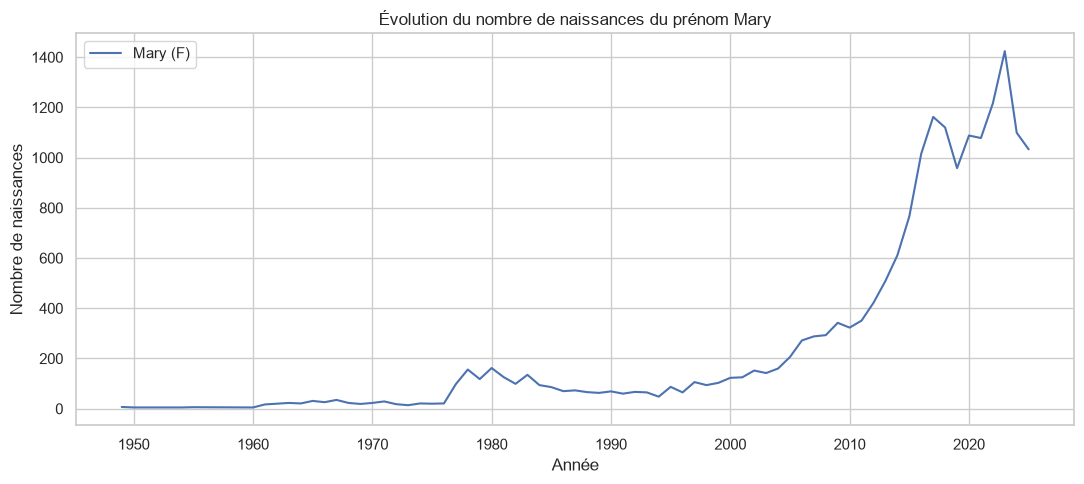

In [98]:
name_data = evolution_prenom("Leia", "F")

plt.figure(figsize=(11, 5))
plt.plot(name_data["year"], name_data["births"], label="Mary (F)")
plt.title("Évolution du nombre de naissances du prénom Mary")
plt.xlabel("Année")
plt.ylabel("Nombre de naissances")
plt.legend()
plt.tight_layout()
plt.show()


### 4.2 Comparer plusieurs prénoms


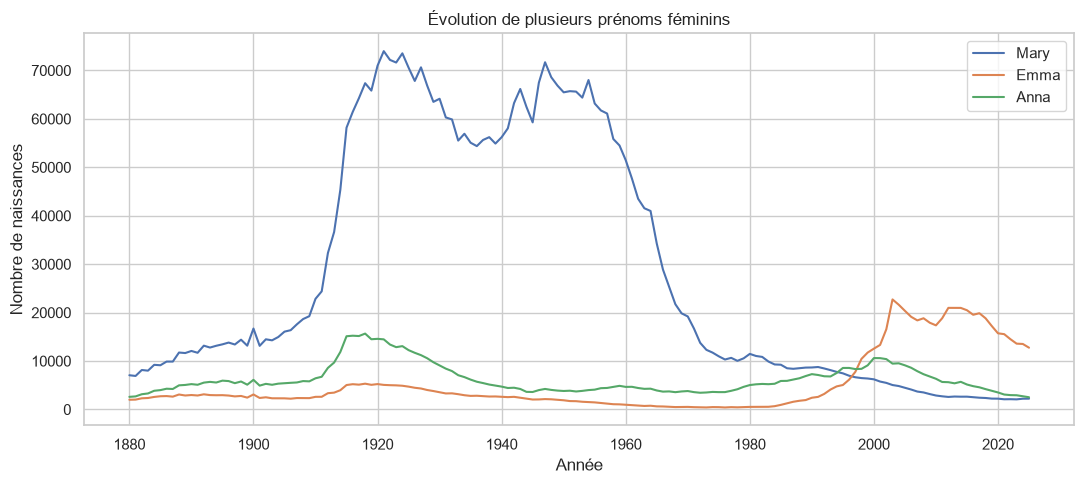

In [99]:
names_to_compare = ["Mary", "Emma", "Anna"]

plt.figure(figsize=(11, 5))

for name in names_to_compare:
    data = evolution_prenom(name, "F")
    plt.plot(data["year"], data["births"], label=name)

plt.title("Évolution de plusieurs prénoms féminins")
plt.xlabel("Année")
plt.ylabel("Nombre de naissances")
plt.legend()
plt.tight_layout()
plt.show()


### 4.3 Total des naissances par genre

Cette visualisation permet de comparer l'évolution des naissances associées aux prénoms féminins et masculins.


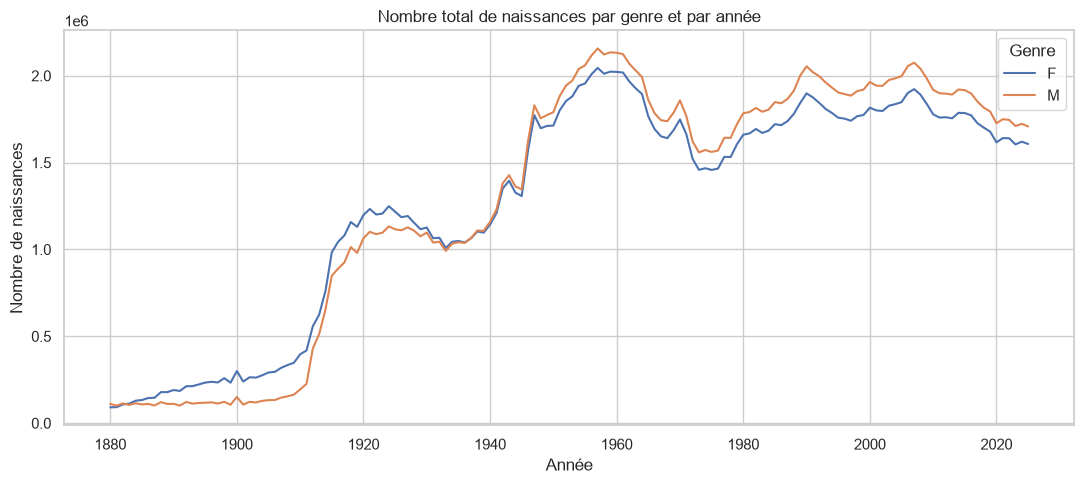

In [100]:
plot_genre = pivot_genre.sort_index()

plt.figure(figsize=(11, 5))
plt.plot(plot_genre.index, plot_genre["F"], label="F")
plt.plot(plot_genre.index, plot_genre["M"], label="M")
plt.title("Nombre total de naissances par genre et par année")
plt.xlabel("Année")
plt.ylabel("Nombre de naissances")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()


### 4.4 Heatmap : popularité par décennie

On construit une matrice avec les 10 prénoms féminins les plus fréquents sur l'ensemble du jeu, puis on observe leur total par décennie.


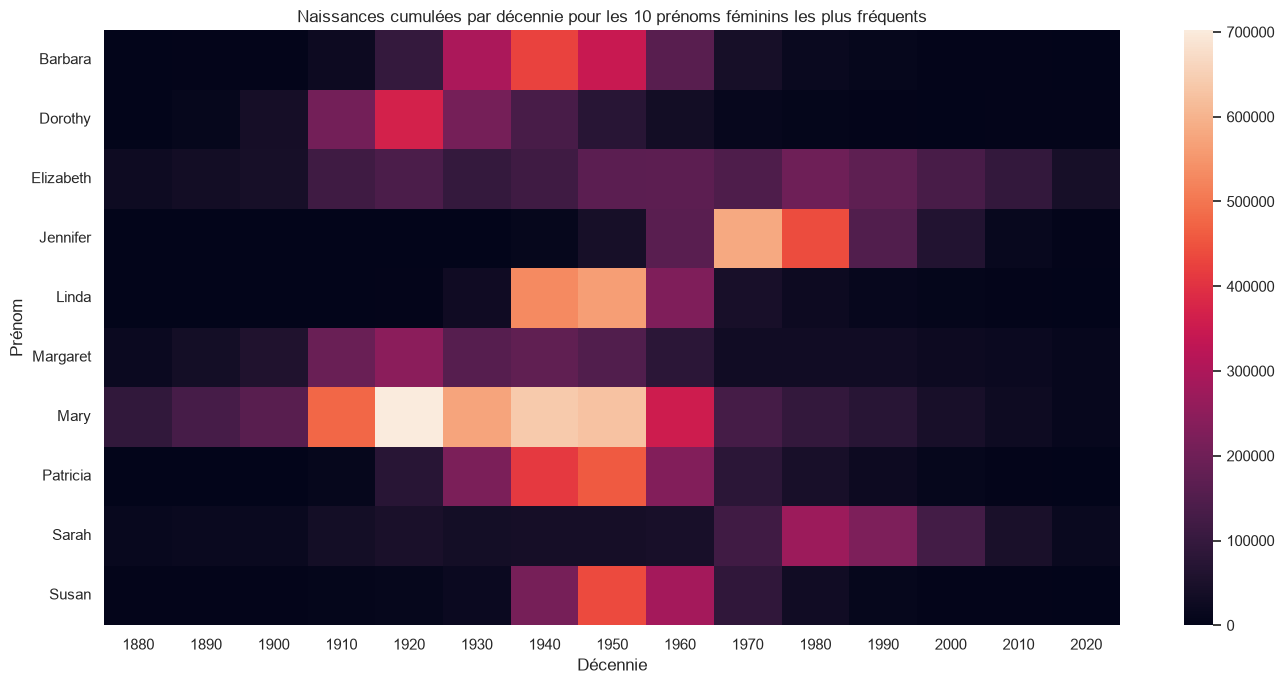

In [101]:
top_female_names = (
    names_df[names_df["genre"] == "F"]
    .groupby("name")["births"]
    .sum()
    .nlargest(10)
    .index
)

heatmap_data = (
    names_df[
        (names_df["genre"] == "F") &
        (names_df["name"].isin(top_female_names))
    ]
    .groupby(["name", "decade"])["births"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, annot=False)
plt.title("Naissances cumulées par décennie pour les 10 prénoms féminins les plus fréquents")
plt.xlabel("Décennie")
plt.ylabel("Prénom")
plt.tight_layout()
plt.show()


### 4.6 Visualiser la longueur des prénoms


In [ ]:
length_counts = names_df["name_length"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
sns.barplot(x=length_counts.index, y=length_counts.values)
plt.title("Nombre de lignes selon la longueur du prénom")
plt.xlabel("Longueur du prénom")
plt.ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()


## 5. Synthèse


Utiliser les données "live births" du tableau démographiques des usa pour proposer des métriques plus pertinentes.
